# Project 1 — CatBoost
## Product Return Prediction (categorical-heavy)

Predicting whether an online order will be returned, using mostly categorical features: product category, brand, shipping method, payment method — plus numeric price. Showcases CatBoost's native categorical handling.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 900
category = np.random.choice(['Electronics','Clothing','Home','Beauty','Toys'], n)
brand = np.random.choice(['BrandA','BrandB','BrandC','BrandD'], n)
shipping_method = np.random.choice(['Standard','Express','NextDay'], n)
payment_method = np.random.choice(['CreditCard','PayPal','COD'], n)
price = np.random.gamma(3, 40, n)

return_risk = (
    (category=='Clothing').astype(int)*0.3
    + (shipping_method=='NextDay').astype(int)*0.15
    + (payment_method=='COD').astype(int)*0.25
    + (price>150).astype(int)*0.2
    + np.random.normal(0,0.15,n)
)
returned = (return_risk > np.percentile(return_risk, 70)).astype(int)

df = pd.DataFrame({'category': category, 'brand': brand, 'shipping_method': shipping_method,
                    'payment_method': payment_method, 'price': price, 'returned': returned})
df.head()


,category,brand,shipping_method,payment_method,price,returned
0,Beauty,BrandC,NextDay,PayPal,124.738276,0
1,Toys,BrandD,Standard,PayPal,191.117629,0
2,Home,BrandB,Express,PayPal,323.306672,1
3,Toys,BrandC,NextDay,PayPal,39.582795,0
4,Toys,BrandC,NextDay,COD,89.842979,1


## 2. Preprocessing

In [3]:
cat_features = ['category', 'brand', 'shipping_method', 'payment_method']
X = df.drop('returned', axis=1)
y = df['returned']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# No encoding needed -- CatBoost handles cat_features natively


## 3. Train Model

In [4]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6,
                            cat_features=cat_features, verbose=0, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.7666666666666667
Precision: 0.7666666666666667
Recall: 0.7666666666666667
F1: 0.7666666666666667

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       126
           1       0.61      0.61      0.61        54

    accuracy                           0.77       180
   macro avg       0.72      0.72      0.72       180
weighted avg       0.77      0.77      0.77       180



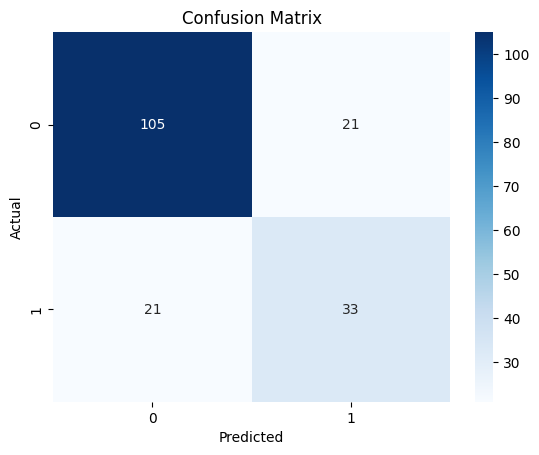

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- Notice we passed raw string columns directly — no `pd.get_dummies` or `LabelEncoder` needed, unlike every other model so far.
- Check `model.get_feature_importance()` to see which categorical/numeric features mattered most.
- Next steps: compare against one-hot-encoding + XGBoost on the same data to feel the preprocessing time CatBoost saves you.

---